In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.fingerprinter import Fingerprinter
from utils.visualization import plot_regression_histograms

from xgboost import XGBRegressor

%load_ext autoreload
%autoreload 2

## Datasets

In [2]:
train = pd.read_csv('../train_clean.csv')
test = pd.read_csv('../test_clean.csv')
properties = train.columns[1:]

In [3]:
fingerprinter = Fingerprinter()

train_X = fingerprinter(train['SMILES'].tolist())
test_X = fingerprinter(test['SMILES'].tolist())

n_features = train_X.shape[1]
print(f'Fingerprints have {n_features} features')

Fingerprints have 2048 features


## XGB Models

In [4]:
params = dict(
    learning_rate = 0.1, 
    gamma = 0., 
    min_child_weight = 3, 
    subsample = 0.8, 
    colsample_bytree = 0.8, 
    max_depth = 7, 
    n_estimators = 200, 
    reg_alpha=1
)

xgbr_dict = {property_label : XGBRegressor(**params)
            for property_label in properties}

In [5]:
for property_label, xgbr in xgbr_dict.items():

    print(f'Training XGB Regressor for {property_label}...', end='')

    train_Y = train[property_label]
    xgbr.fit(train_X, train_Y)
    
    print(f'Done')

Training XGB Regressor for Viability Mask 1...Done
Training XGB Regressor for Viability Mask 2...Done
Training XGB Regressor for LPS Abs...Done
Training XGB Regressor for LPS Lum...Done
Training XGB Regressor for MPLA Abs...Done
Training XGB Regressor for MPLA Lum...Done
Training XGB Regressor for CpG Abs...Done
Training XGB Regressor for cGAMP Abs...Done
Training XGB Regressor for cGAMP Lum...Done
Training XGB Regressor for LMCpG Abs...Done
Training XGB Regressor for LMcGAMP Lum...Done


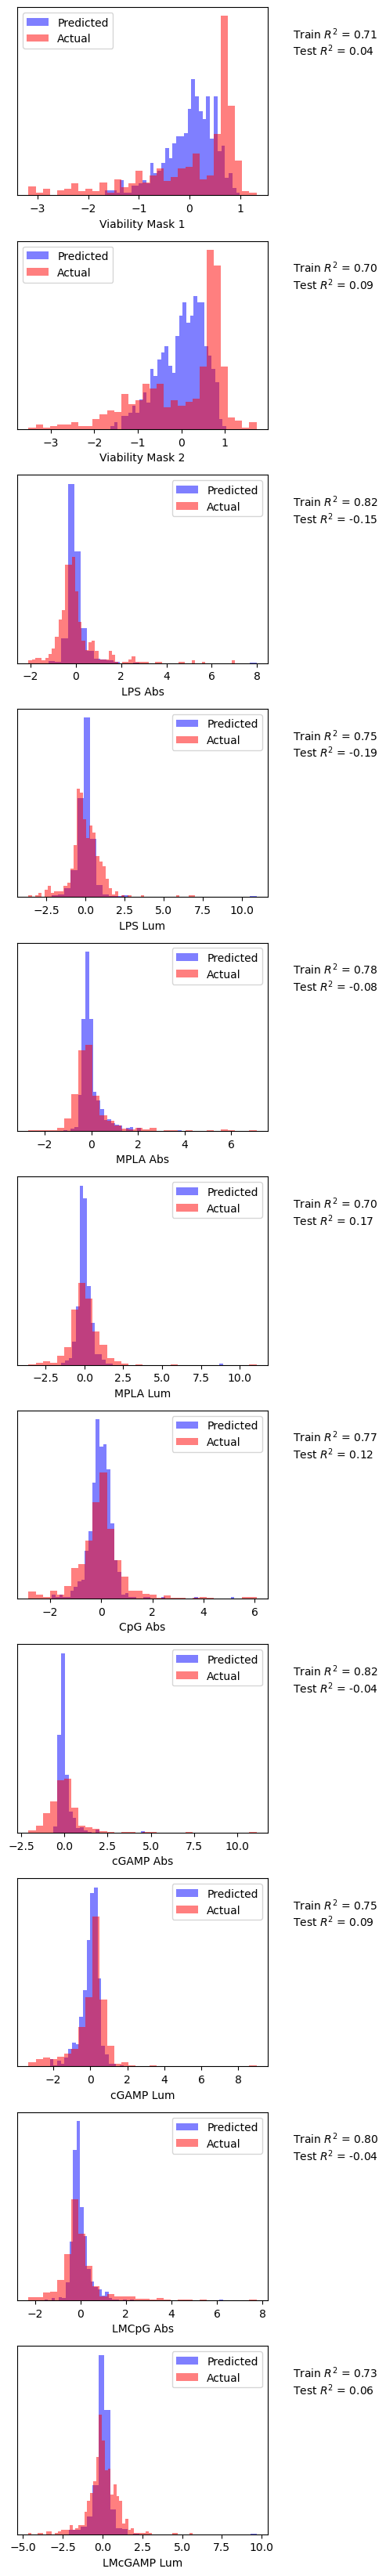

In [7]:
plot_regression_histograms(xgbr_dict, train_X, test_X, test, train)